## 관찰 데이터에서 인과관계를 말할 수 있는가?

BRFSS2015 건강 설문 데이터 70,692건으로 야채 섭취가 당뇨에 미치는 영향을 분석했다.  
단순 비율 비교에서는 "야채 섭취군의 당뇨 발생률이 9.71%p 낮다"는 결론이 나왔다.  
하지만 PSM으로 선택 편향을 제거하자 결론이 역전됐다 —  
야채를 먹는 사람이 원래부터 건강에 신경 쓰는 사람이었던 것이다.  
그 역전이 왜 일어났는지 추적하는 것이 이 분석의 핵심이다.

**분석 진행 내용**
- 두 그룹 사건율 비교 (Z-test, 카이제곱 검정)
- 효과 크기 산출 (ARR, RR, OR, NNT)
- 공변량 보정 (로지스틱 회귀, Adjusted OR)
- 성향점수 매칭 (PSM, 1:1 최근접 이웃 매칭)
- 매칭 품질 검증 (SMD, Love Plot)

---

# 1. 당뇨 데이터 A/B 테스트 : 야채 섭취 여부가 당뇨에 미치는 영향 살펴보기

### 분석 설계
- 연구 질문
  - 하루에 한번 이상 야채를 섭취하는 그룹과 그렇지 않은 그룹의 당뇨 발생률 비교.
  - `Veggies` : 하루 한번 이상 야채를 섭취하는지 유무 데이터. 0 = no, 1 = yes
- **가설**
    - H0(귀무가설): 두 그룹의 당뇨 발생률은 동일하다.
    - H1(대립가설): 두 그룹의 당뇨 발생률은 다르다.

In [1]:
import pandas as pd
import numpy as np
from math import isfinite
from scipy.stats import chi2_contingency
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep
from statsmodels.stats.contingency_tables import Table2x2
import matplotlib.pyplot as plt
import platform

# 운영체제별 한글 폰트 자동 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:  # Linux
    plt.rc('font', family='DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 데이터 출처: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
# 파일명: diabetes_binary_5050split_health_indicators_BRFSS2015.csv
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.columns = [c.lower() for c in df.columns]
df


,diabetes_binary,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0


In [3]:
# 분석에 필수인 두 컬럼에만 dropna 적용
# 나머지 결측은 공변량 보정 단계에서 별도 처리 — 지금 전부 제거하면 표본이 과도하게 줄어든다
df = df.dropna(subset=["diabetes_binary", "veggies"])
df["treat"] = df["veggies"].astype(int)     # 야채 섭취 여부 → 처치변수 (1=섭취, 0=비섭취)
df["outcome"] = df["diabetes_binary"].astype(int)  # 당뇨 여부 → 결과변수

print(df[["treat","outcome"]].head())

   treat  outcome
0      1        0
1      0        0
2      1        0
3      1        0
4      1        0


In [4]:
summary = (
    df.groupby("treat")["outcome"]
    .agg(events="sum", total="count", rate="mean")
    .reset_index().replace({0:'Control', 1:'Treatment'})
)

summary['rate'] = (summary['rate']*100).round(2)
summary

# 야채를 섭취한 그룹의 당뇨 발생률 : 48%
# 야채를 섭취하지 않은 그룹의 당뇨 발생률 : 58%

,treat,events,total,rate
0,Control,8610,14932,57.66
1,Treatment,26736,55760,47.95


# Z-test (비율 비교)

In [5]:
# Z-test: 두 그룹의 비율 차이가 통계적으로 유의한지 검정
# n이 충분히 크면(이 데이터는 7만 건) 이항분포를 정규분포로 근사할 수 있어 z-통계량 사용
e_t, n_t = df.loc[df['treat'] == 1, "outcome"].sum(), (df['treat'] == 1).sum()
e_c, n_c = df.loc[df['treat'] == 0, "outcome"].sum(), (df['treat'] == 0).sum()

stat, pval = sm.stats.proportions_ztest([e_t, e_c], [n_t, n_c])
print(stat)
print(pval)

-21.082435549914262
1.152952205999821e-98


# 카이제곱 검정

In [6]:
# 카이제곱: Z-test와 동일한 가설을 독립성 검정 관점에서 재확인
# 수학적으로 z² = chi2 로 동치지만, 관점이 다르다
# 두 방법이 같은 결론을 내면 결과 신뢰도가 올라간다
contingency_table = pd.crosstab(df["treat"], df["outcome"])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(chi2)
print(p_val)

444.0806516898606
1.4007103685991128e-98


# 효과크기지표

In [7]:
# p-value만으로는 '얼마나 다른지'를 알 수 없다 — 효과 크기를 별도로 본다
# ARR: 절대 위험 감소 — 두 그룹 발생률의 차이. 가장 직관적
# RR:  상대 위험 — 야채군이 비야채군 대비 몇 배 위험한가
# OR:  오즈비 — 로지스틱 회귀 Adjusted OR과 직접 비교 가능
# NNT: 당뇨 1건을 예방하려면 몇 명을 야채 섭취시켜야 하는가 (정책 해석에 유용)
p1, p0 = e_t/n_t, e_c/n_c
ARR = p0 - p1
RR = p1/p0
OR  = (e_t*(n_c-e_c))/((n_t-e_t)*e_c)
NNT = 1/ARR if ARR>0 else np.inf

print(f"Treatment 사건율: {p1:.2%}, Control 사건율: {p0:.2%}")
print(f"ARR={ARR:.2%}, RR={RR:.3f}, OR={OR:.3f}, NNT={NNT:.1f}")
print(f"z-test p={pval:.4f}, Chi2 p={p_val:.4f}")

Treatment 사건율: 47.95%, Control 사건율: 57.66%
ARR=9.71%, RR=0.832, OR=0.676, NNT=10.3
z-test p=0.0000, Chi2 p=0.0000


### 해석
- 원데이터로 A/B 테스트를 진행한 결과, 야채를 섭취한 그룹과 섭취하지 않은 그룹 간 당뇨 발생률에 유의한 차이(p<0.001) 가 있었다.
- ARR = 9.71% → 야채 섭취 그룹의 당뇨 발생률이 약 9.71%p 낮았다.
- RR = 0.83 → 야채 섭취 그룹의 위험은 대조군 대비 약 17% 낮았다.
- OR = 0.67 → 야채 섭취 그룹의 오즈는 약 33% 낮았다.
- NNT = 10.3 → 약 10명을 야채 섭취시키면 당뇨 1건을 예방할 수 있다.

---
### 🤔 이 결과를 그대로 믿을 수 있을까?

통계적으로 유의미하고(p < 0.001) 효과 크기도 명확하다. 하지만 이 비교에는 구조적 문제가 있다.

야채를 매일 먹는 사람은 그렇지 않은 사람과 **처음부터 다를 수 있다**.  
운동을 더 하고, 건강검진을 더 받고, 술을 덜 마시는 경향이 있다면 —  
당뇨율 차이는 야채 때문이 아니라, 이 사람들의 전반적인 건강 습관 때문일 수 있다.

이를 **혼란변수(confounding)** 문제라고 한다.  
나이, 운동, BMI 등 관련 변수를 로지스틱 회귀로 보정해 OR을 다시 보는 것이 첫 번째 시도다.

# 공변량 보정

In [8]:
# 당뇨 발생에 영향을 주면서, 동시에 야채 섭취 여부와도 상관된 변수들을 골랐다
# → treat(야채섭취)와 outcome(당뇨) 모두에 영향을 주는 변수여야 혼란변수 조건을 충족
# age, sex 등은 5050 split으로 이미 균형이 맞춰진 상태라 제외
# veggies(처치변수 자체)는 당연히 제외
covars = ['highchol', 'cholcheck', 'bmi', 'stroke', 'heartdiseaseorattack', 'physactivity',
          'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'genhlth', 'menthlth', 'physhlth', 'diffwalk']

# 1) 원본에서 분석에 필요한 칼럼만 복사
use_cols = ["outcome", "treat"] + covars  # covars는 앞에서 정의된 공변량 리스트
df_lr = df[use_cols].copy()

# 2) 범주형(문자/객체) → 원-핫 인코딩 (첫 범주 드롭)
cat_col = [c for c in df_lr.columns if df_lr[c].dtype == "object"]
df_lr = pd.get_dummies(df_lr, columns=cat_col, drop_first=True)

# 3) 수치형 강제 변환 (문자/기호가 있으면 NaN으로)
for c in df_lr.columns:
    df_lr[c] = pd.to_numeric(df_lr[c], errors='coerce')

# 결측 제거
df_lr = df_lr.dropna(axis=0)

# 4) X, y 구성 + 상수항
y = df_lr["outcome"].astype(float).values
X = df_lr.drop(columns=["outcome"])
X = sm.add_constant(X).astype(float)


# 5) 로지스틱 적합
logit = sm.Logit(y, X).fit(disp=0)

# 6) 효과 및 신뢰구간 확인
or_adj = float(np.exp(logit.params['treat']))
ci_l, ci_u = np.exp(logit.conf_int().loc["treat"])
p_adj = float(logit.pvalues["treat"])

print("\n[공변량 보정(Logit, 안전버전)]")
print(f"Adjusted OR = {or_adj:.3f} (95% CI {ci_l:.3f}–{ci_u:.3f}), p = {p_adj:.4f}")



[공변량 보정(Logit, 안전버전)]
Adjusted OR = 0.873 (95% CI 0.836–0.911), p = 0.0000


### 해석
- 공변량을 로지스틱 회귀에 함께 넣으면, 해당 변수들을 동일하게 통제한 상태에서 야채 섭취만의 순수한 효과(Adjusted OR)를 분리할 수 있다.
- Adjusted OR = 0.873 → 야채 섭취 그룹의 당뇨 오즈는 대조군 대비 약 13% 낮았다.
- raw OR(0.676) → 0.873으로 줄어든 것은, 초기 효과의 일부가 야채가 아닌 전반적인 건강 습관에서 온 것임을 의미한다.

---
### 🤔 공변량 보정으로 충분한가?

Adjusted OR이 0.676 → 0.873으로 줄었다. 보정 효과가 있었다.  
하지만 로지스틱 회귀 보정에는 한계가 있다.

모델에 넣지 못한 변수, 측정되지 않은 특성이 여전히 남아 있다면 보정은 불완전하다.  
무엇보다 "야채를 선택한 사람들"이라는 **선택 편향(selection bias)** 자체를 제거하지는 못한다.

더 강한 방법이 필요하다: **성향점수 매칭(PSM)**.  
야채를 먹는 사람과 거의 동일한 특성을 가진 안 먹는 사람을 1:1 매칭해,  
마치 랜덤 배정 실험처럼 비교하는 구조를 만든다.

# 성향점수 매칭 : PSM

In [9]:
# 성향점수 추정: 공변량으로 로지스틱 회귀를 적합해 각 샘플이 처치군일 확률을 구한다
X_cov = df[covars]

# StandardScaler: 로지스틱 회귀는 피처 스케일에 민감하다
# BMI(수십 단위)와 이진변수(0/1)를 그대로 쓰면 계수가 왜곡되므로 정규화 필요
scaler = StandardScaler()
Xs = scaler.fit_transform(X_cov)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(Xs, df['treat'])
df['pscore'] = ps_model.predict_proba(Xs)[:,1]  # [:,1]: 처치군(야채섭취)일 확률 = 성향점수

# 1:1 최근접 이웃 매칭
# 처치군 1명당 성향점수가 가장 가까운 대조군 1명을 짝지음
# 1:N 매칭보다 균형이 좋아지고, 구조가 단순해 해석이 명확해진다
treated, control = df[df["treat"]==1], df[df["treat"]==0]
nn = NearestNeighbors(n_neighbors=1).fit(control[["pscore"]])
dist, idx = nn.kneighbors(treated[["pscore"]])
mc = control.iloc[idx.flatten()]
mt = treated.reset_index(drop=True)

### 성향점수 매칭 후 사건율 계산 및 통계 검정

In [10]:
mc

,diabetes_binary,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,menthlth,physhlth,diffwalk,sex,age,education,income,treat,outcome,pscore
15479,0.0,0.0,0.0,1.0,22.0,1.0,0.0,0.0,1.0,0.0,...,0.0,6.0,1.0,1.0,3.0,5.0,7.0,0,0,0.850584
29438,0.0,0.0,0.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,...,0.0,10.0,0.0,0.0,11.0,6.0,8.0,0,0,0.878179
37164,1.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,0.0,10.0,6.0,6.0,0,1,0.822161
2000,0.0,0.0,0.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,4.0,5.0,1.0,0,0,0.850691
1493,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,10.0,6.0,6.0,0,0,0.822119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,10.0,6.0,8.0,0,0,0.754741
52471,1.0,1.0,1.0,1.0,35.0,0.0,0.0,1.0,1.0,1.0,...,0.0,6.0,1.0,1.0,8.0,5.0,5.0,0,1,0.775529
43389,1.0,1.0,0.0,1.0,38.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,7.0,6.0,8.0,0,1,0.797285
61627,1.0,1.0,1.0,1.0,37.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,12.0,4.0,2.0,0,1,0.665999


In [11]:
p1_m, p0_m = mt["outcome"].mean(), mc["outcome"].mean()
cont_m = np.array([[mt["outcome"].sum(), len(mt)-mt["outcome"].sum()],  # 사건수  # 비사건수 
                   [mc["outcome"].sum(), len(mc)-mc["outcome"].sum()]])
cont_m, pval_m, *_ = chi2_contingency(cont_m)


In [12]:
# 효과크기
ARR = p0_m - p1_m
RR = p1_m/p0_m

print(f"Treatment 사건율: {p1_m:.2%}, Control 사건율: {p0_m:.2%}")
print(f"ARR={ARR:.2%}, RR={RR:.3f}")
print(f"Chi2 p={pval_m:.4f}")

Treatment 사건율: 47.95%, Control 사건율: 40.77%
ARR=-7.18%, RR=1.176
Chi2 p=0.0000


### 해석
- 성향점수매칭 후 A/B 테스트를 진행한 결과, 야채를 섭취한 그룹과 섭취하지 않은 그룹 간 당뇨 발생률에 유의한 차이(p<0.001) 가 있었다.
- 하지만 매칭된 대조군의 사건 발생률이 뒤집어짐.

### 1️⃣ 왜 PSM 후 사건율이 뒤집힐 수 있나?
- (1) 원래 데이터 = “혼란변수(confounding) 섞인 비교”   
예: 야채 먹는 사람은 평균적으로 나이가 더 적고, 건강습관이 좋다 → 이 자체가 당뇨율 낮춤.    
그래서 원자료에서는 “야채 섭취군이 당뇨 적다” 로 보일 수 있음.    

- (2) PSM = “비슷한 사람끼리 붙여놓고 비교”   
성향점수 매칭은 나이, 성별, 운동습관, 소득 등 공변량을 비슷하게 맞춘 사람끼리 페어링.   
즉, 야채 먹는 사람과 거의 같은 특성의 안 먹는 사람만 비교하는 셈.     

👉 그랬더니, 원래 “야채 먹는 사람이 건강해서 당뇨율이 낮아 보였던 착시”가 사라지고,   
실제는 오히려 야채 먹는 그룹에서 사건율이 더 높게 나올 수 있음.    

매칭 전 사건율(발생률):
 treat
대조군    0.576614
실험군    0.479484
Name: outcome, dtype: float64

매칭 후 사건율(발생률):
 treat
대조군    0.407676
실험군    0.479484
Name: outcome, dtype: float64


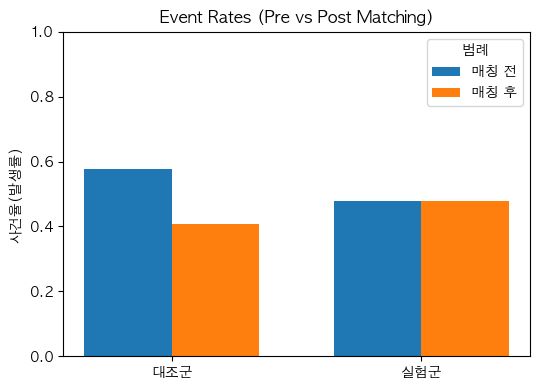


SMD 표(상위 10개):
                      변수          유형   SMD_매칭전   SMD_매칭후
0          physactivity      binary  0.351573  0.014510
1               genhlth  continuous  0.285605  0.019958
2              diffwalk      binary  0.199663  0.000254
3              physhlth  continuous  0.164255  0.018162
4                   bmi  continuous  0.138707  0.008328
5              menthlth  continuous  0.128449  0.047556
6                stroke      binary  0.110146  0.001943
7              highchol      binary  0.105157  0.010372
8           nodocbccost      binary  0.087876  0.025564
9  heartdiseaseorattack      binary  0.086810  0.013173


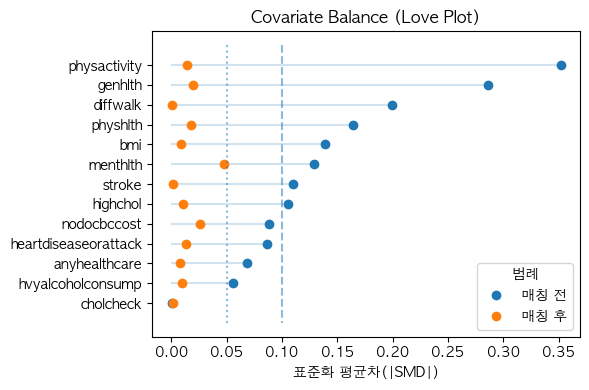


[해석 팁]
- Love plot에서 파란 점(매칭 후)이 세로선 0.1 안쪽으로 들어오면 균형이 꽤 좋아진 것.
- 사건율 막대에서 매칭 전/후 차이가 크게 달라졌다면, confounding 보정 효과가 컸다는 의미.


In [13]:
# PSM이 실제로 잘 됐는지 확인: 매칭 전후 사건율 비교 + 공변량 균형 검증
# 매칭했다고 끝이 아니다 — 두 그룹이 실제로 비슷해졌는지 직접 확인해야 한다

matched = pd.concat([
    mt.assign(treat=1, matched=1),
    mc.assign(treat=0, matched=1)
], ignore_index=True)  # with-replacement 매칭이므로 중복 제거 없이 그대로 합침

def event_rate(df_like):
    return df_like.groupby("treat")["outcome"].mean().rename({0:"대조군", 1:"실험군"})

pre_rates = event_rate(df.assign(matched=0))
post_rates = event_rate(matched)

print("매칭 전 사건율:\n", pre_rates)
print("\n매칭 후 사건율:\n", post_rates)

fig, ax = plt.subplots(figsize=(5.5, 4))
width = 0.35
x = np.arange(2)
ax.bar(x - width/2, [pre_rates["대조군"], pre_rates["실험군"]], width, label="매칭 전")
ax.bar(x + width/2, [post_rates["대조군"], post_rates["실험군"]], width, label="매칭 후")
ax.set_xticks(x)
ax.set_xticklabels(["대조군", "실험군"])
ax.set_ylabel("사건율")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# SMD: 공변량 균형이 얼마나 개선됐는지 수치로 확인
# |SMD| ≤ 0.1이면 두 그룹 간 해당 변수 분포가 충분히 비슷해진 것으로 본다

def _is_binary(s):
    vals = s.dropna().unique()
    # unique값이 2개 이하이고, 그 값이 모두 0/1/True/False 안에 들어오면 이진변수로 판단
    # issubset: A.issubset(B) → A의 모든 원소가 B에 포함되면 True
    return len(vals) <= 2 and set(vals).issubset({0, 1, True, False})

def _smd_cont(x_t, x_c):
    mt, mc = np.mean(x_t), np.mean(x_c)
    st, sc = np.std(x_t, ddof=1), np.std(x_c, ddof=1)  # ddof=1: 표본 표준편차
    # pooled SD: 두 그룹의 분산을 표본 크기로 가중 평균한 합동 표준편차
    pooled = np.sqrt(((len(x_t)-1)*st**2 + (len(x_c)-1)*sc**2) / (len(x_t)+len(x_c)-2))
    return 0.0 if pooled == 0 else (mt - mc) / pooled

def _smd_binary(x_t, x_c):
    pt, pc = np.mean(x_t), np.mean(x_c)  # 이진변수의 mean = 해당 값의 비율(proportion)
    p = (pt + pc) / 2  # 두 그룹 비율의 평균 → 분모 기준값
    # 이진변수의 표준편차: sqrt(p*(1-p)), 연속형과 분모 계산 방식이 다름
    denom = np.sqrt(p * (1 - p)) if 0 < p < 1 else 0
    return 0.0 if denom == 0 else (pt - pc) / denom

def compute_smd_table(df_pre, df_post, covars, treat_col="treat"):
    rows = []
    for v in covars:
        x_t_pre  = df_pre.loc[df_pre[treat_col]==1, v]
        x_c_pre  = df_pre.loc[df_pre[treat_col]==0, v]
        x_t_post = df_post.loc[df_post[treat_col]==1, v]
        x_c_post = df_post.loc[df_post[treat_col]==0, v]
        if _is_binary(df_pre[v]):
            smd_pre  = _smd_binary(x_t_pre, x_c_pre)
            smd_post = _smd_binary(x_t_post, x_c_post)
            vtype = "binary"
        else:
            smd_pre  = _smd_cont(x_t_pre, x_c_pre)
            smd_post = _smd_cont(x_t_post, x_c_post)
            vtype = "continuous"
        rows.append({"변수": v, "유형": vtype, "SMD_매칭전": abs(smd_pre), "SMD_매칭후": abs(smd_post)})
    return pd.DataFrame(rows).sort_values("SMD_매칭전", ascending=False).reset_index(drop=True)

smd_tab = compute_smd_table(df, matched, covars)
print("\nSMD 표(상위 10개):\n", smd_tab.head(10))

# Love Plot: 변수별 SMD를 매칭 전후로 시각화
# 파란 점(매칭 후)이 점선(0.1) 안쪽으로 들어올수록 균형이 잘 맞춰진 것
fig, ax = plt.subplots(figsize=(6, max(4, 0.3*len(smd_tab))))
ypos = np.arange(len(smd_tab))
ax.hlines(y=ypos, xmin=0, xmax=smd_tab["SMD_매칭전"], alpha=0.2)  # 매칭 전 기준선
ax.plot(smd_tab["SMD_매칭전"], ypos, "o", label="매칭 전")
ax.plot(smd_tab["SMD_매칭후"], ypos, "o", label="매칭 후")
ax.vlines(0.1, -1, len(smd_tab), linestyles="dashed", alpha=0.5, label="|SMD|=0.1")
ax.vlines(0.05, -1, len(smd_tab), linestyles="dotted", alpha=0.3)
ax.set_title("Covariate Balance (Love Plot)")
ax.set_xlabel("|SMD|")
ax.set_yticks(ypos)
ax.set_yticklabels(smd_tab["변수"])
ax.invert_yaxis()  # 위에서부터 SMD 큰 순으로 보기 위해 y축 뒤집기
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 📚 개념 정리

### Adjusted OR (공변량 보정 오즈비)
로지스틱 회귀에 공변량(BMI, 운동, 고혈압 등)을 함께 넣으면, 그 변수들이 동일한 조건일 때 처치 효과만의 순수한 오즈비를 분리할 수 있다.  
raw OR과 비교해 Adjusted OR이 줄어들었다면, 초기 효과의 일부가 처치가 아닌 혼란변수에서 온 것이다.

$$OR = \frac{p_t / (1-p_t)}{p_c / (1-p_c)}$$

분자는 처치군의 오즈, 분모는 대조군의 오즈. OR=1이면 효과 없음, OR<1이면 처치군의 사건 오즈가 더 낮다.

---

### 효과 크기 지표

$$ARR = p_c - p_t \quad \text{(절대 위험 감소: 두 그룹 발생률 차이)}$$

$$RR = \frac{p_t}{p_c} \quad \text{(상대 위험: 처치군이 대조군 대비 몇 배 위험한가)}$$

$$NNT = \frac{1}{ARR} \quad \text{(사건 1건 예방에 필요한 처치 인원 수)}$$

---

### PSM (성향점수 매칭)
관찰 데이터에서는 처치군과 대조군이 처음부터 다른 특성을 가질 수 있다(선택 편향).  
PSM은 각 샘플이 처치군에 속할 확률(성향점수)을 로지스틱 회귀로 추정한 뒤, 성향점수가 비슷한 사람끼리 1:1로 매칭한다.

$$e(x) = P(T=1 \mid X=x) \quad \text{(성향점수: 공변량 x가 주어졌을 때 처치군일 확률)}$$

---

### SMD (표준화 평균차)
매칭 전후 공변량 균형이 얼마나 개선됐는지 확인. $|SMD| \leq 0.1$ 이면 충분히 균형이 맞춰진 것으로 본다.

**연속형 변수:**
$$SMD = \frac{\bar{x}_t - \bar{x}_c}{s_{pooled}}, \quad s_{pooled} = \sqrt{\frac{(n_t-1)s_t^2 + (n_c-1)s_c^2}{n_t+n_c-2}}$$

**이진 변수:**
$$SMD = \frac{p_t - p_c}{\sqrt{\bar{p}(1-\bar{p})}}, \quad \bar{p} = \frac{p_t + p_c}{2}$$

이진변수는 분산이 $p(1-p)$ 형태이므로 연속형과 분모 계산 방식이 다르다.

---

### Confounding vs Selection Bias
- **Confounding**: 처치와 결과 모두에 영향을 주는 제3의 변수. 로지스틱 회귀 보정으로 통제.
- **Selection Bias**: 처치군과 대조군이 처음부터 다른 특성을 가지는 구조적 문제. PSM으로 완화.

이 둘은 원인이 다르고 해결 방법도 다르다.

---
## 🔍 회고

### 한계
PSM은 모델에 넣은 공변량만 통제한다. 측정하지 못한 혼란변수(예: 식습관 전반, 가족력)가 있다면 매칭 후에도 선택 편향이 완전히 제거됐다고 보기 어렵다.  
또한 1:1 매칭에서 대조군 표본이 중복 사용될 수 있어, 매칭 후 표준 오차가 과소 추정될 가능성이 있다.

### 다음에 해보고 싶은 것
- **Caliper 설정**: 성향점수 차이가 너무 큰 쌍은 매칭하지 않도록 허용 범위를 제한해보기
- **IPW (역확률 가중치)**: 매칭 대신 가중치를 부여해 전체 표본을 활용하는 방법 시도
- **민감도 분석**: 관측되지 않은 혼란변수가 있다면 결론이 얼마나 달라지는지 확인 (Rosenbaum bounds)

통계는 공식보다 '언제 어떤 방법을 쓰는가'를 판단하는 게 더 어렵다는 걸 이번에 체감했다. 공부할 게 많다.